# Vira Games User Segmentation

## 1. Problem framing

Goal: build a practical user segmentation for the Vira Games mobile portfolio that supports lifecycle messaging, monetization, and re-engagement decisions.

This notebook is intentionally concise. It focuses on the end-to-end segmentation story:

1. data overview
2. EDA highlights
3. feature engineering rationale
4. segmentation model comparison
5. final segment profiles
6. business recommendations
7. caveats and next steps


In [1]:
from __future__ import annotations

from pathlib import Path
import random
import sys

import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.analysis.eda_kpis import run_eda
from src.analysis.profile_segments import run_profiling
from src.data.load_data import load_all_datasets
from src.features.build_user_features import build_user_feature_mart, save_user_feature_mart
from src.models.segmentation import run_segmentation
from src.utils.config import DEFAULT_RANDOM_SEED

random.seed(DEFAULT_RANDOM_SEED)
np.random.seed(DEFAULT_RANDOM_SEED)
pd.set_option("display.max_columns", 100)
DEFAULT_RANDOM_SEED

42

## 2. Data overview

The raw project data is provided as four flat files. A key modeling constraint is that `users.csv` contains multiple installs for some users while the behavioral tables only contain `user_id`, so the final segmentation is built at the portfolio user level rather than the install row level.


In [2]:
datasets = load_all_datasets()
overview = pd.DataFrame(
    {
        "dataset": list(datasets.keys()),
        "rows": [len(df) for df in datasets.values()],
        "columns": [len(df.columns) for df in datasets.values()],
        "unique_users": [df["user_id"].nunique() if "user_id" in df.columns else np.nan for df in datasets.values()],
    }
)
overview

,dataset,rows,columns,unique_users
0,users,59398,6,50000
1,sessions,2797416,6,50000
2,transactions,265166,5,4918
3,events,2255431,4,49466


In [3]:
users = datasets["users"]
user_grain_note = pd.DataFrame(
    {
        "metric": [
            "Raw user rows",
            "Unique user_id",
            "Users in multiple games",
            "Multi-game share",
        ],
        "value": [
            len(users),
            users["user_id"].nunique(),
            int((users.groupby("user_id")["game_id"].nunique() > 1).sum()),
            f"{(users.groupby('user_id')['game_id'].nunique() > 1).mean():.1%}",
        ],
    }
)
user_grain_note

,metric,value
0,Raw user rows,59398
1,Unique user_id,50000
2,Users in multiple games,7486
3,Multi-game share,15.0%


## 3. EDA highlights

The optional EDA section is kept lightweight and focused on signals that justify the segmentation design. The reusable `run_eda()` function regenerates the KPI figures used in the written findings.


In [4]:
eda_results = run_eda()

eda_summary = pd.DataFrame(
    [
        ("Average DAU", round(eda_results["time_kpis"]["dau"].mean(), 0)),
        ("Average WAU", round(eda_results["time_kpis"]["wau"].mean(), 0)),
        ("Average MAU", round(eda_results["time_kpis"]["mau"].mean(), 0)),
        ("Mean stickiness", f"{eda_results['time_kpis']['stickiness'].mean():.1%}"),
        ("Payer conversion", f"{eda_results['revenue_metrics']['payer_conversion_rate']:.1%}"),
        ("ARPPU", f"${eda_results['revenue_metrics']['arppu']:,.2f}"),
        ("Top 5% payer revenue share", f"{eda_results['revenue_metrics']['revenue_top_5_percent_share']:.1%}"),
    ],
    columns=["metric", "value"],
)
eda_summary

,metric,value
0,Average DAU,5490.0
1,Average WAU,15456.0
2,Average MAU,23040.0
3,Mean stickiness,27.3%
4,Payer conversion,9.3%
5,ARPPU,$349.71
6,Top 5% payer revenue share,56.7%


**Dau Wau Mau**

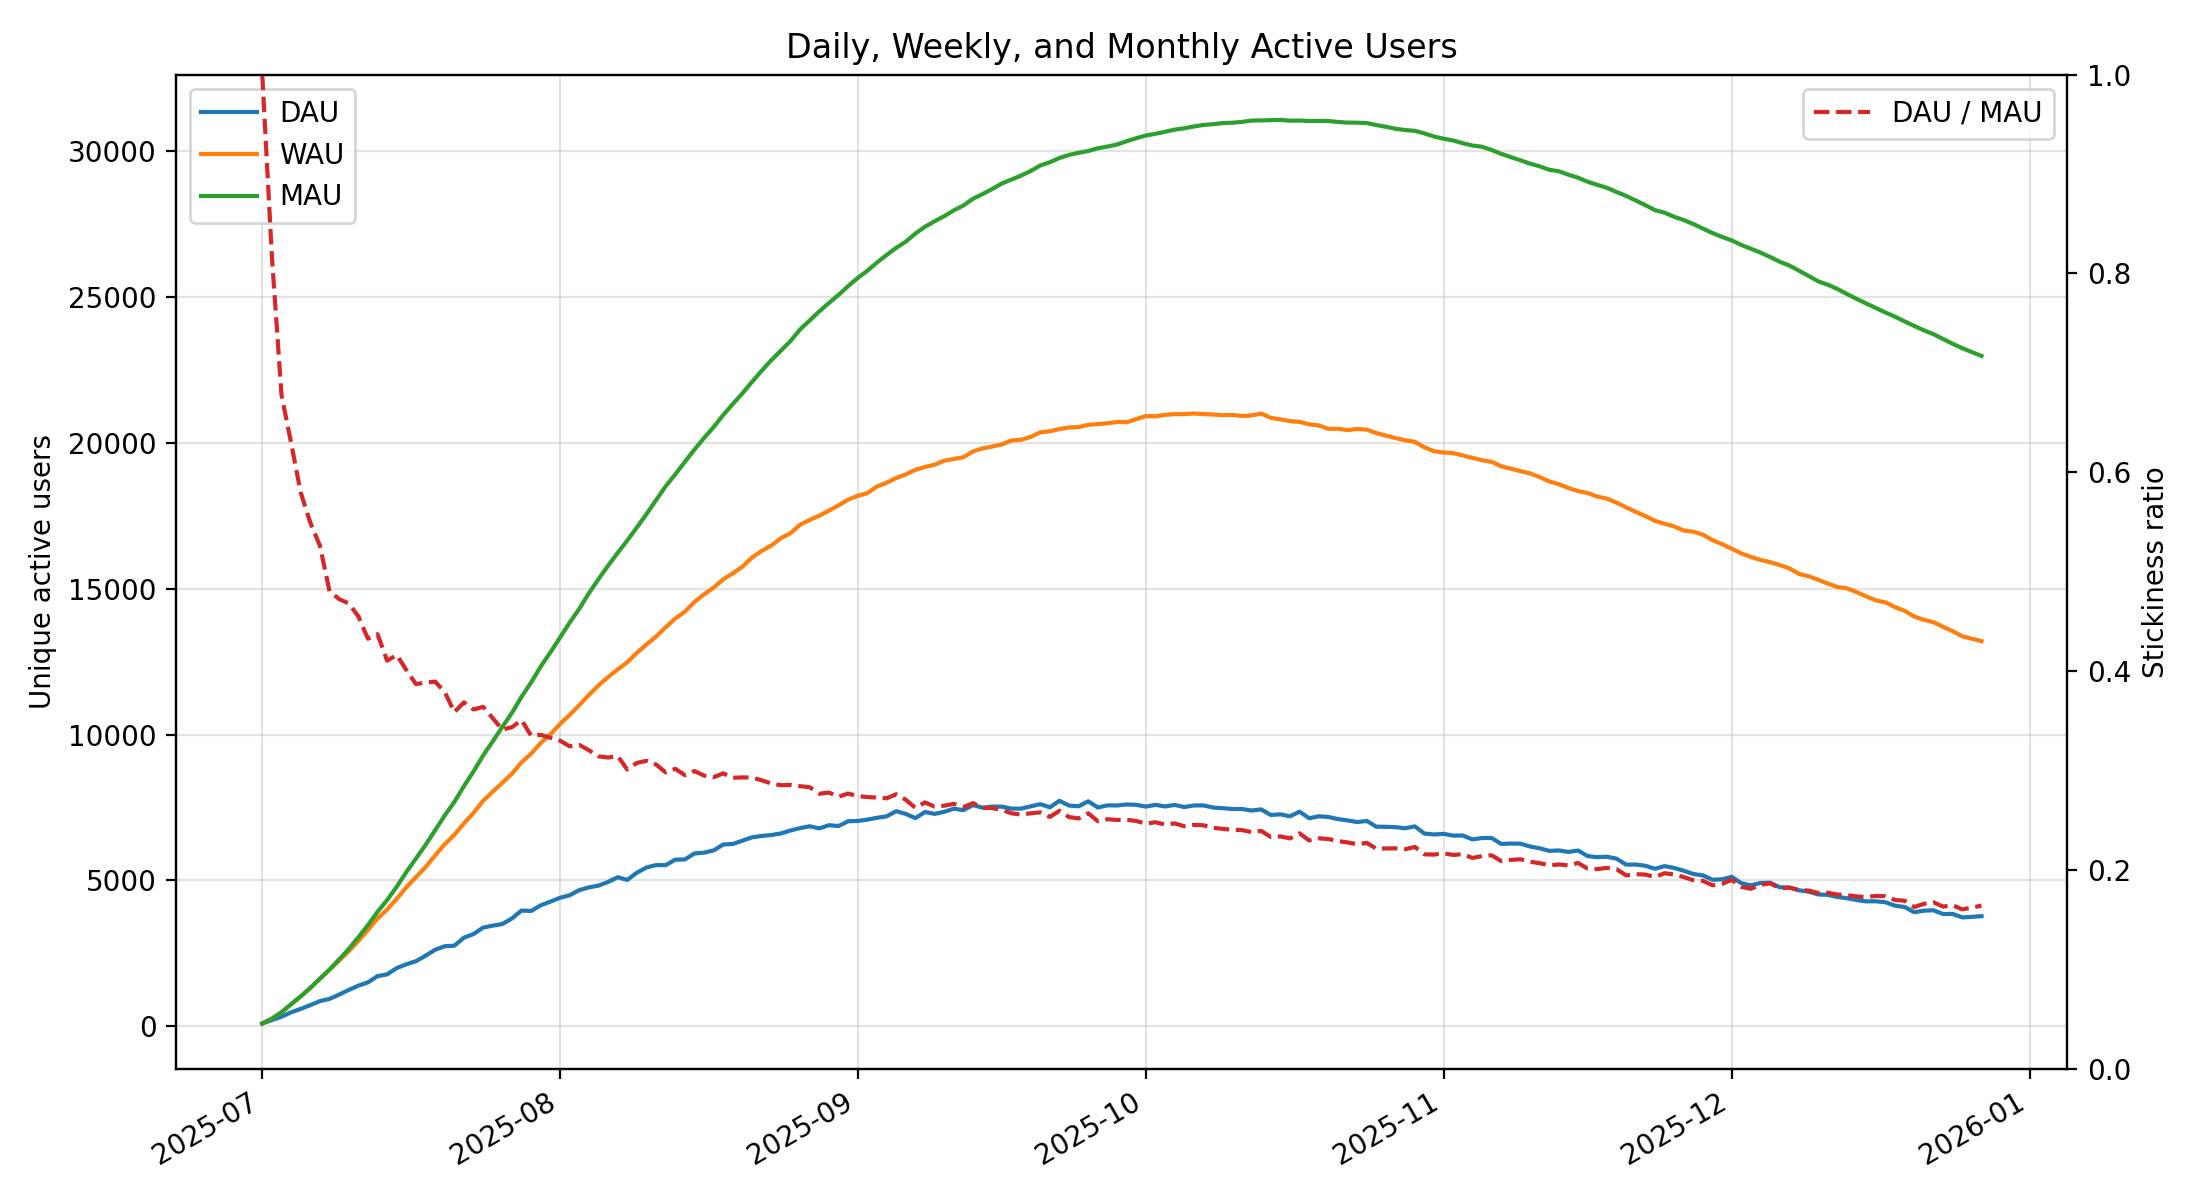

**Retention**

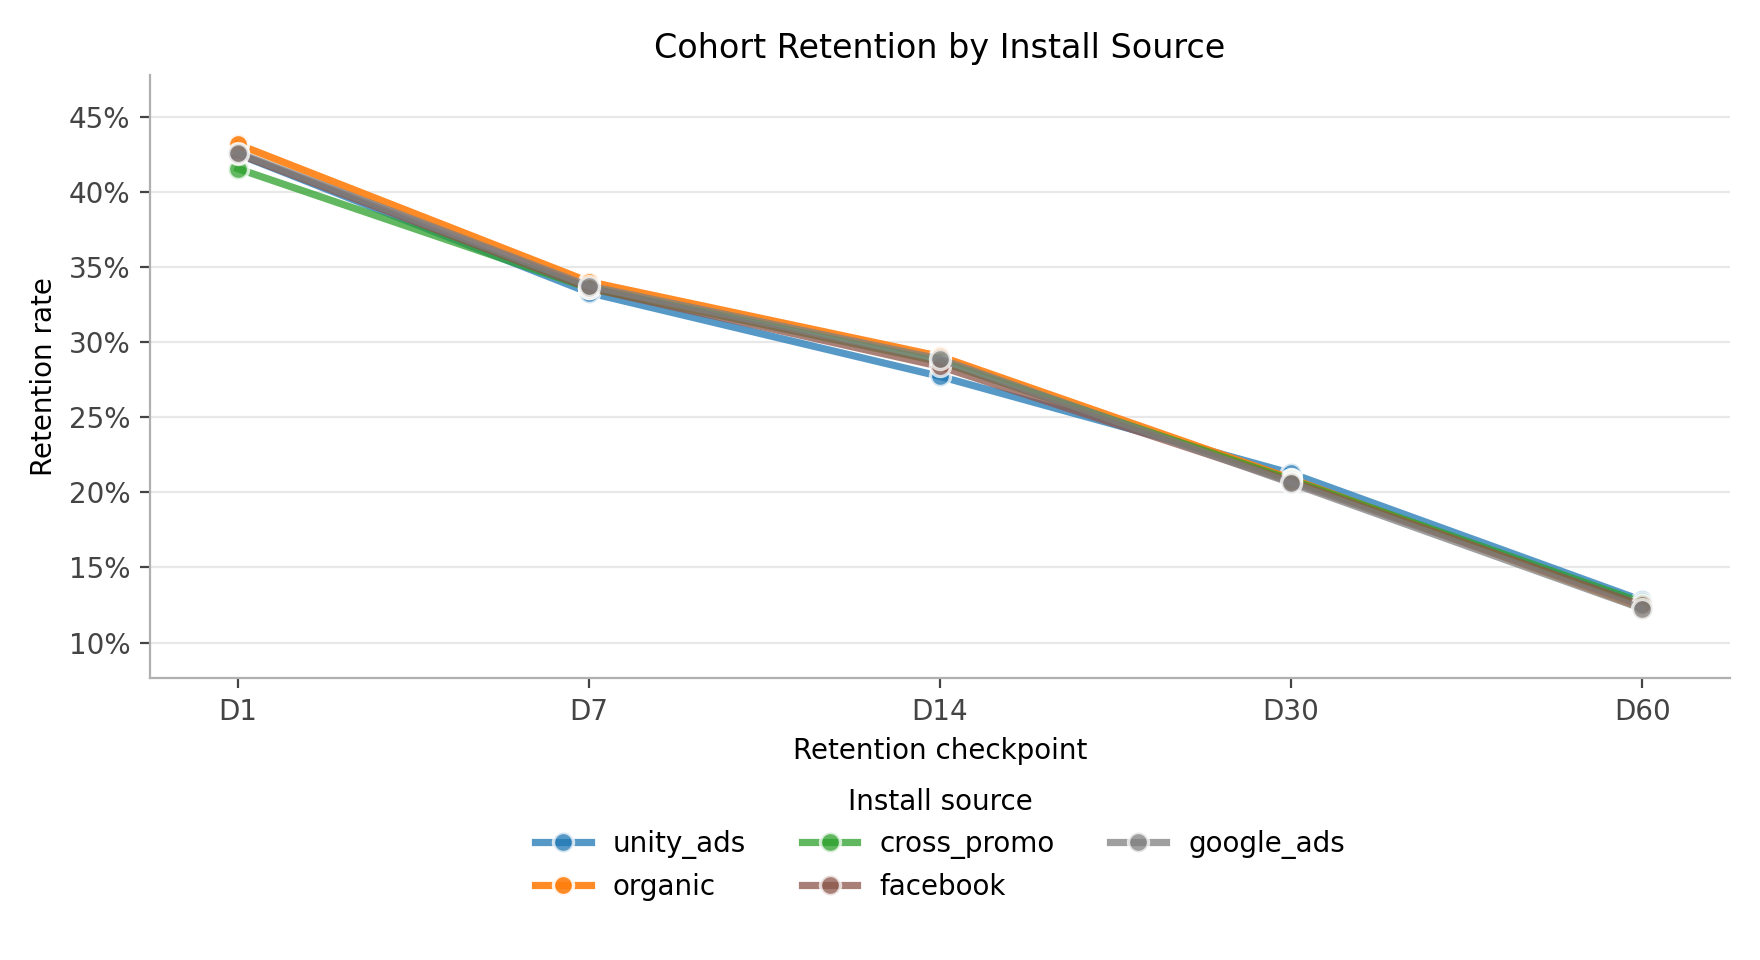

**Revenue Per User**

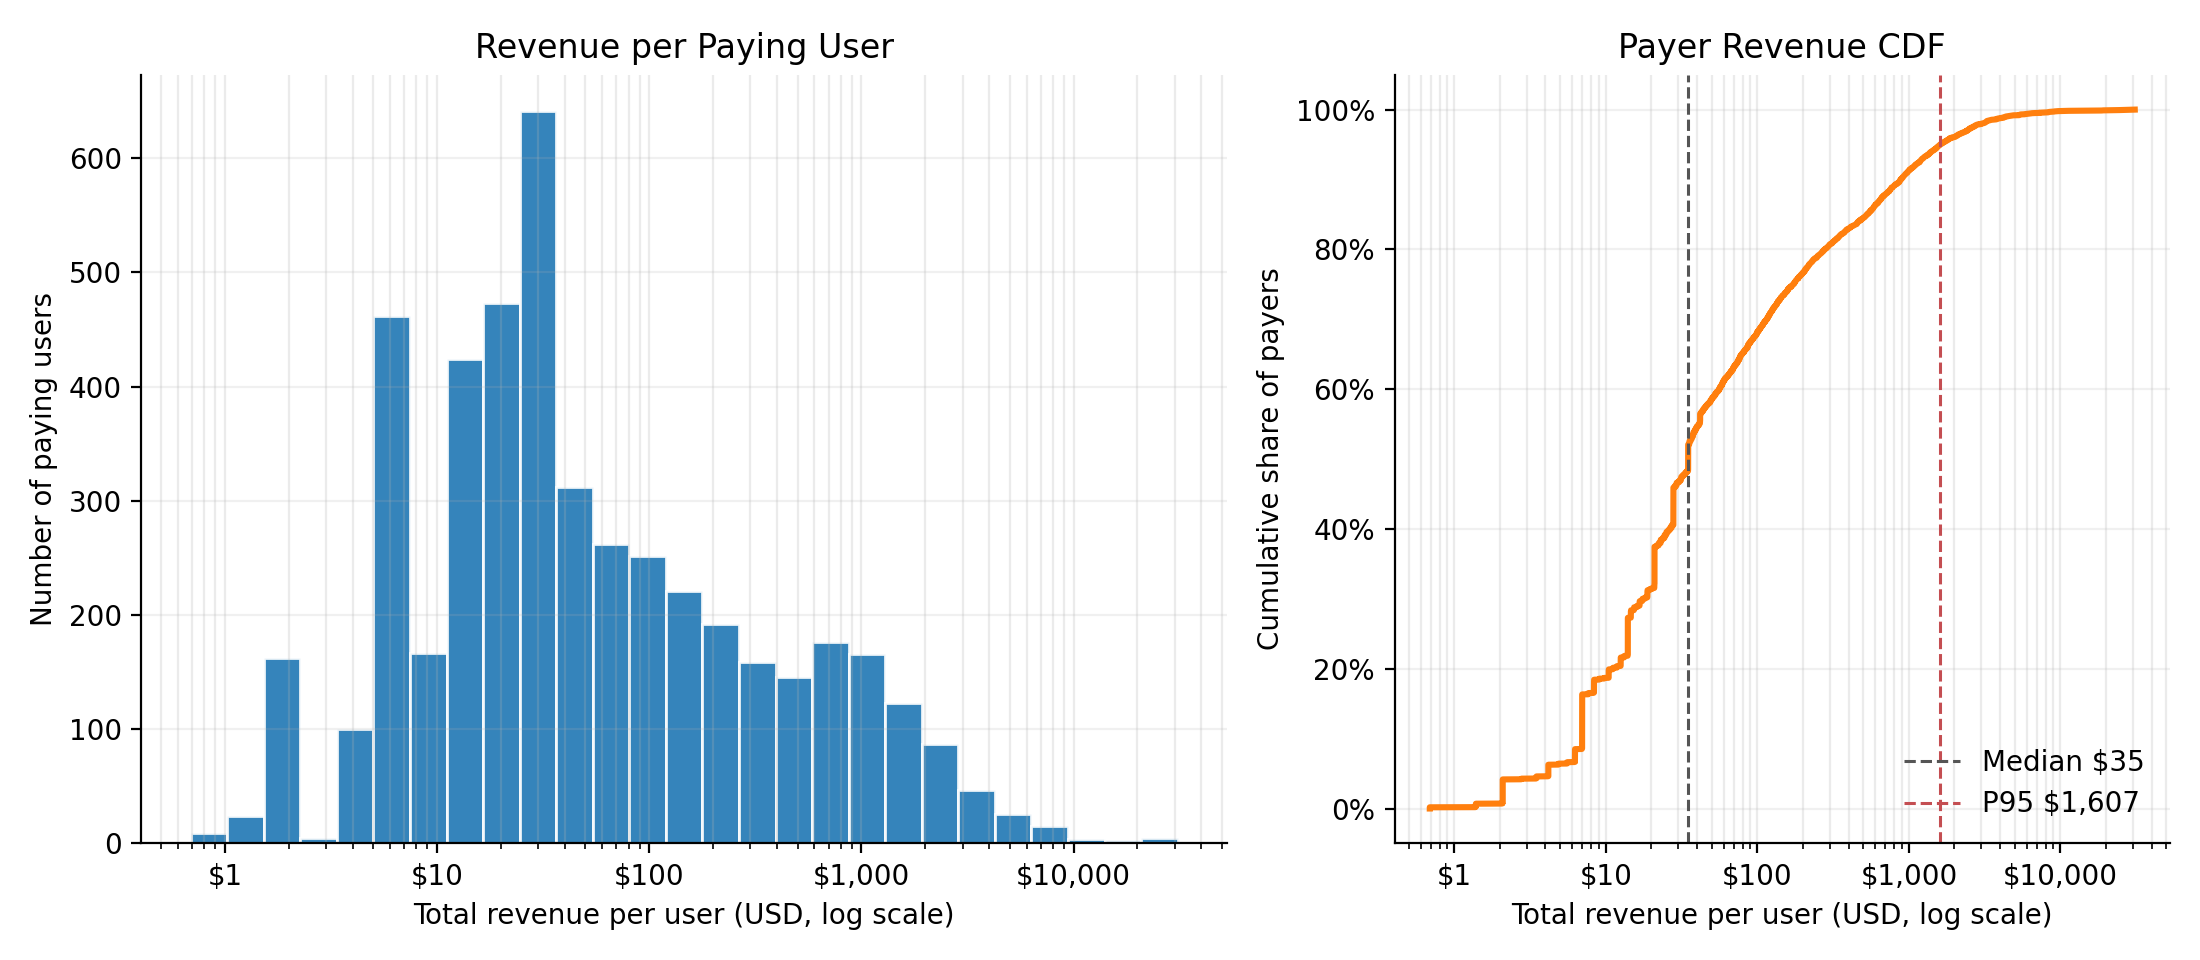

**Session Frequency**

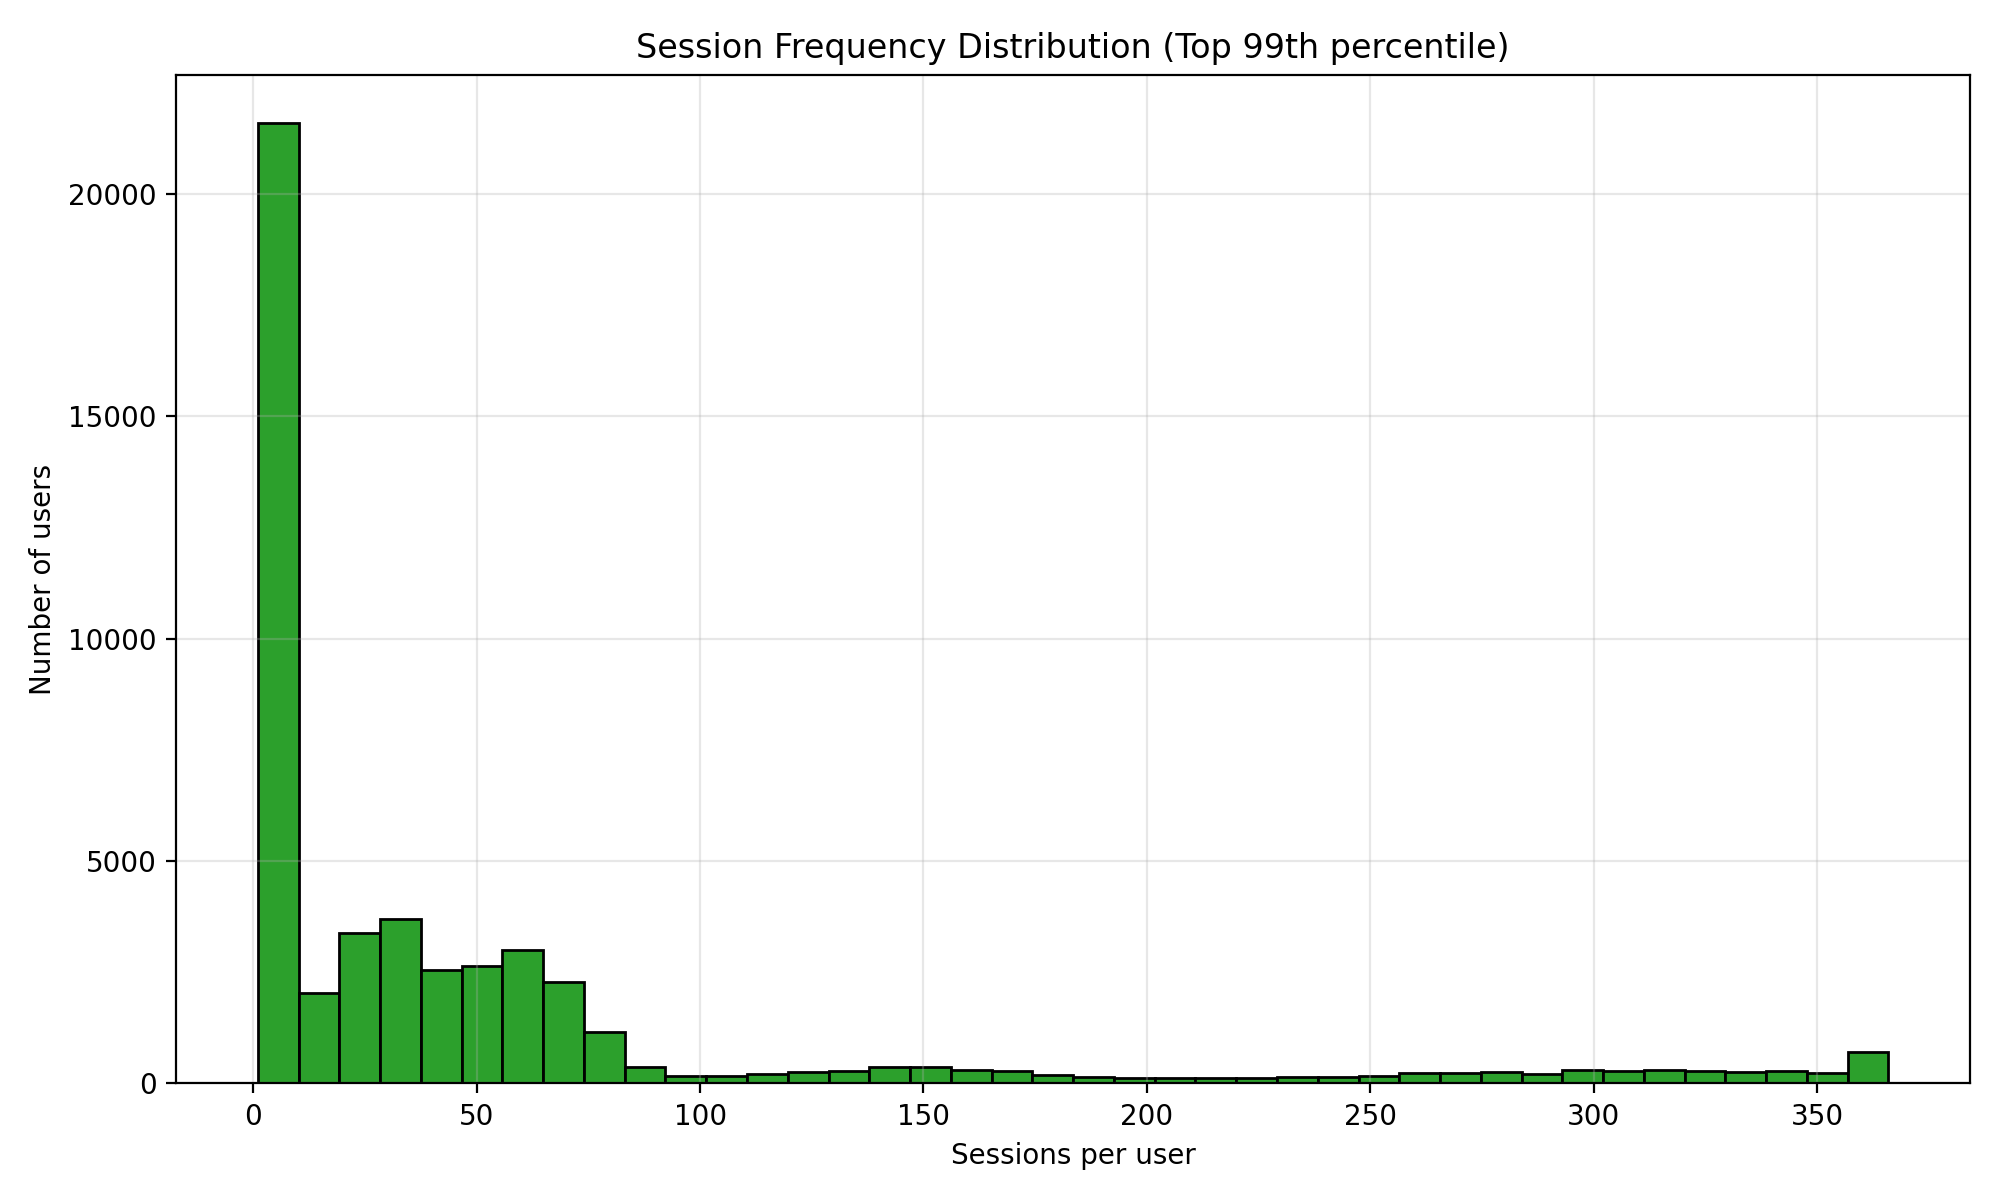

In [5]:
for label in [
    "dau_wau_mau",
    "retention",
    "revenue_per_user",
    "session_frequency",
]:
    display(Markdown(f"**{label.replace('_', ' ').title()}**"))
    display(Image(filename=str(eda_results["figure_paths"][label])))

## 4. Feature engineering rationale

The final feature table is deliberately compact and interview-friendly. It keeps stakeholder-readable raw features and adds `log1p_*` companions only where clustering stability benefits from skew reduction.

Feature groups:

- lifecycle and recency
- RFM
- engagement level and momentum
- progression quality
- monetization behavior
- ads, offers, and push interactions


In [6]:
feature_mart = build_user_feature_mart()
save_user_feature_mart(feature_mart)

feature_snapshot = pd.DataFrame(
    [
        ("Rows", len(feature_mart)),
        ("Unique users", feature_mart["user_id"].nunique()),
        ("Payer rate", f"{feature_mart['payer_flag'].mean():.1%}"),
        ("Subscription payer rate", f"{feature_mart['subscription_payer_flag'].mean():.1%}"),
        ("Median sessions", feature_mart["sessions_total"].median()),
        ("Median recency days", feature_mart["rfm_recency_days"].median()),
        ("Multi-game share", f"{feature_mart['multi_game_user_flag'].mean():.1%}"),
    ],
    columns=["metric", "value"],
)
feature_snapshot

,metric,value
0,Rows,50000
1,Unique users,50000
2,Payer rate,9.3%
3,Subscription payer rate,6.0%
4,Median sessions,24.0
5,Median recency days,53.0
6,Multi-game share,15.0%


In [7]:
selected_columns = [
    "user_id",
    "primary_game_id",
    "primary_install_source",
    "games_installed_count",
    "sessions_total",
    "sessions_last_30d",
    "rfm_recency_days",
    "total_revenue_usd",
    "subscription_revenue_share",
    "ad_watched_per_session",
    "offer_purchase_event_rate",
]
feature_mart[selected_columns].head(10)

,user_id,primary_game_id,primary_install_source,games_installed_count,sessions_total,sessions_last_30d,rfm_recency_days,total_revenue_usd,subscription_revenue_share,ad_watched_per_session,offer_purchase_event_rate
0,u_000000,game_a,google_ads,2,7,0,75,0.0,0.0,0.142857,0.000000
1,u_000001,game_b,google_ads,1,30,8,21,0.0,0.0,0.133333,0.000000
2,u_000002,game_a,facebook,2,3,0,126,0.0,0.0,0.000000,0.000000
3,u_000003,game_c,google_ads,1,2,0,108,0.0,0.0,0.000000,0.000000
4,u_000004,game_d,google_ads,1,82,7,22,0.0,0.0,0.182927,0.083333
5,u_000005,game_d,google_ads,1,1,0,154,0.0,0.0,0.000000,0.000000
6,u_000006,game_d,unity_ads,1,7,0,125,0.0,0.0,0.000000,0.000000
7,u_000007,game_a,organic,1,2,0,146,0.0,0.0,0.000000,0.000000
8,u_000008,game_b,google_ads,1,69,0,47,0.0,0.0,0.231884,0.100000
9,u_000009,game_a,facebook,1,36,0,55,0.0,0.0,0.333333,0.000000


## 5. Segmentation method comparison

Two methods are compared on the same standardized feature set:

- `KMeans`
- `GaussianMixture`

Cluster counts from 3 to 6 are tested. Selection balances separation, segment balance, and interpretability rather than optimizing one metric in isolation.


In [8]:
segmentation_artifacts = run_segmentation()
metrics = segmentation_artifacts.metrics.copy()
metrics

,model,k,silhouette,inertia,bic,aic,min_segment_share,max_segment_share,interpretability_score
0,gmm,3,0.236389,NaN,-4.039499e+06,-4.041210e+06,0.15930,0.59966,1.461779
1,gmm,4,0.269891,NaN,-4.554751e+06,-4.557035e+06,0.06824,0.59956,2.154854
2,gmm,5,0.281539,NaN,-4.640717e+06,-4.643574e+06,0.04526,0.59960,2.406759
3,gmm,6,0.220577,NaN,-4.749598e+06,-4.753028e+06,0.04554,0.59368,2.382227
4,kmeans,3,0.295452,891772.538847,NaN,NaN,0.08978,0.48150,1.557226
5,kmeans,4,0.307031,758428.695878,NaN,NaN,0.06372,0.45232,2.241231
6,kmeans,5,0.319311,679242.817675,NaN,NaN,0.04420,0.45222,2.485764
7,kmeans,6,0.269087,619382.468917,NaN,NaN,0.04424,0.44558,2.504421


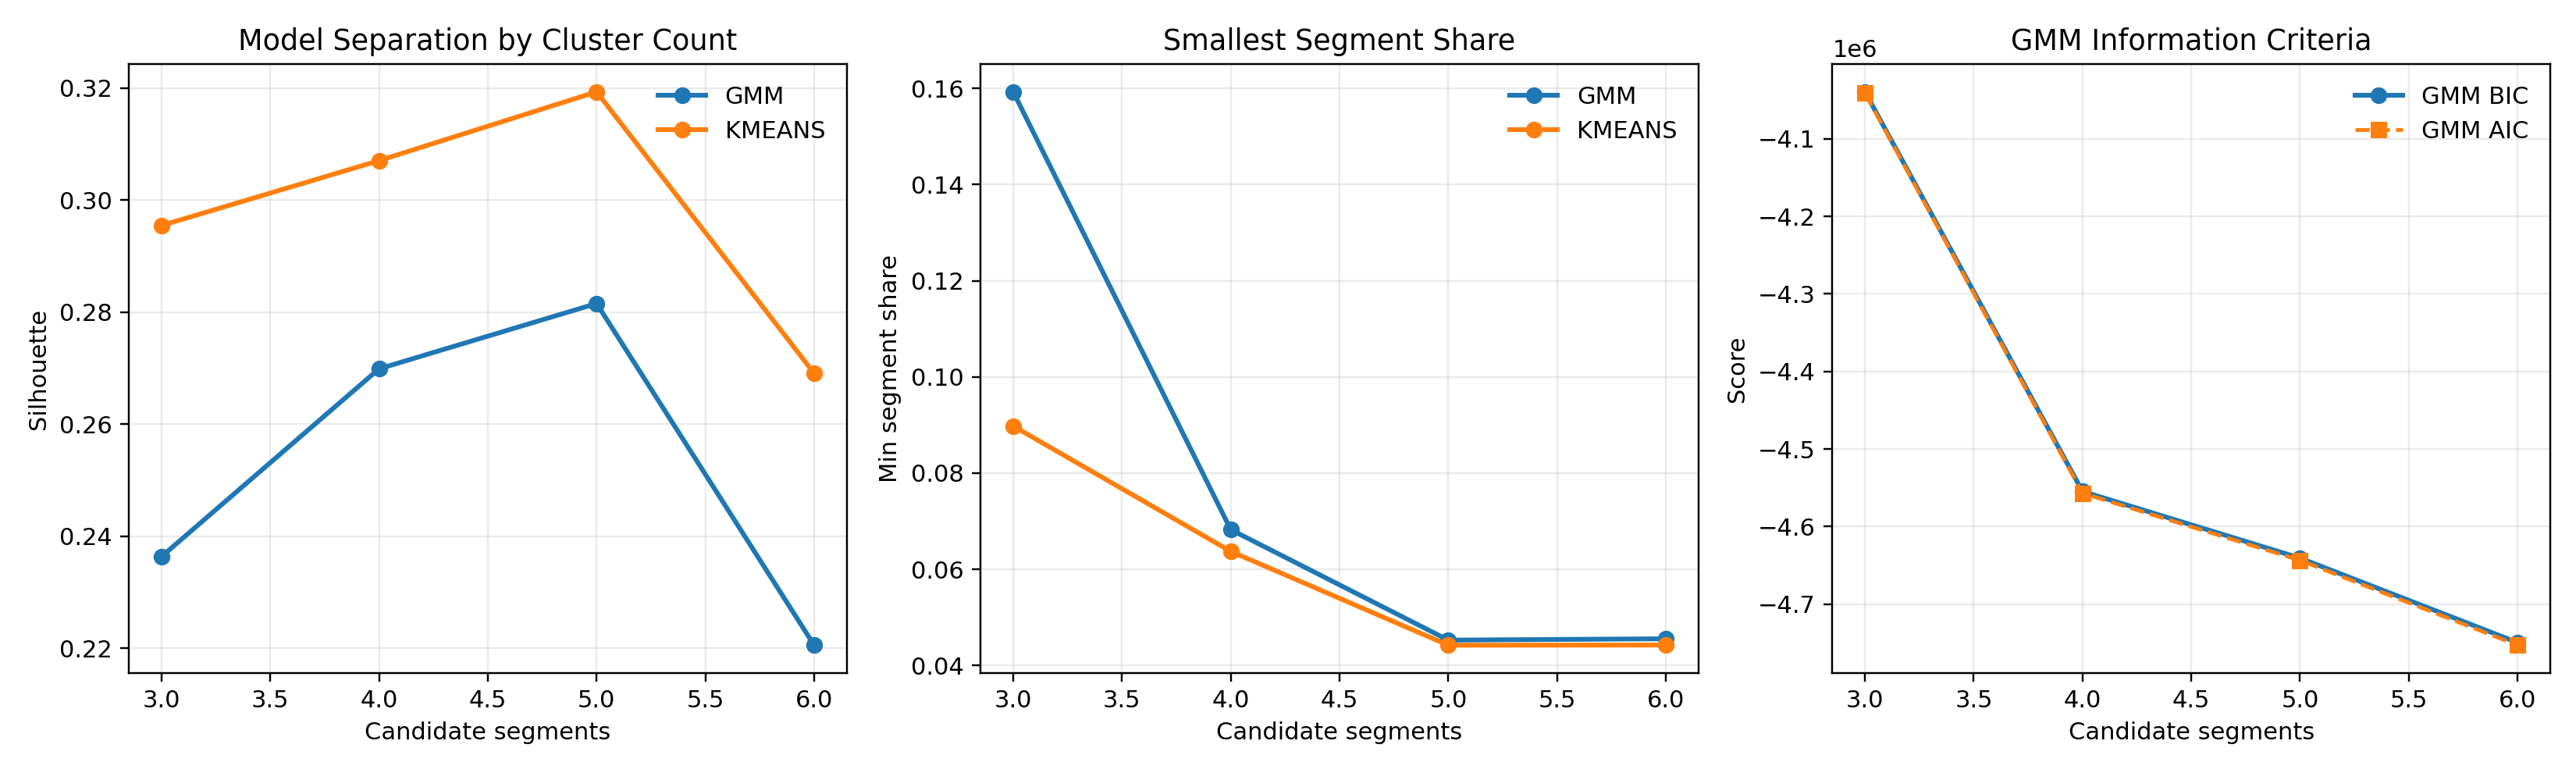

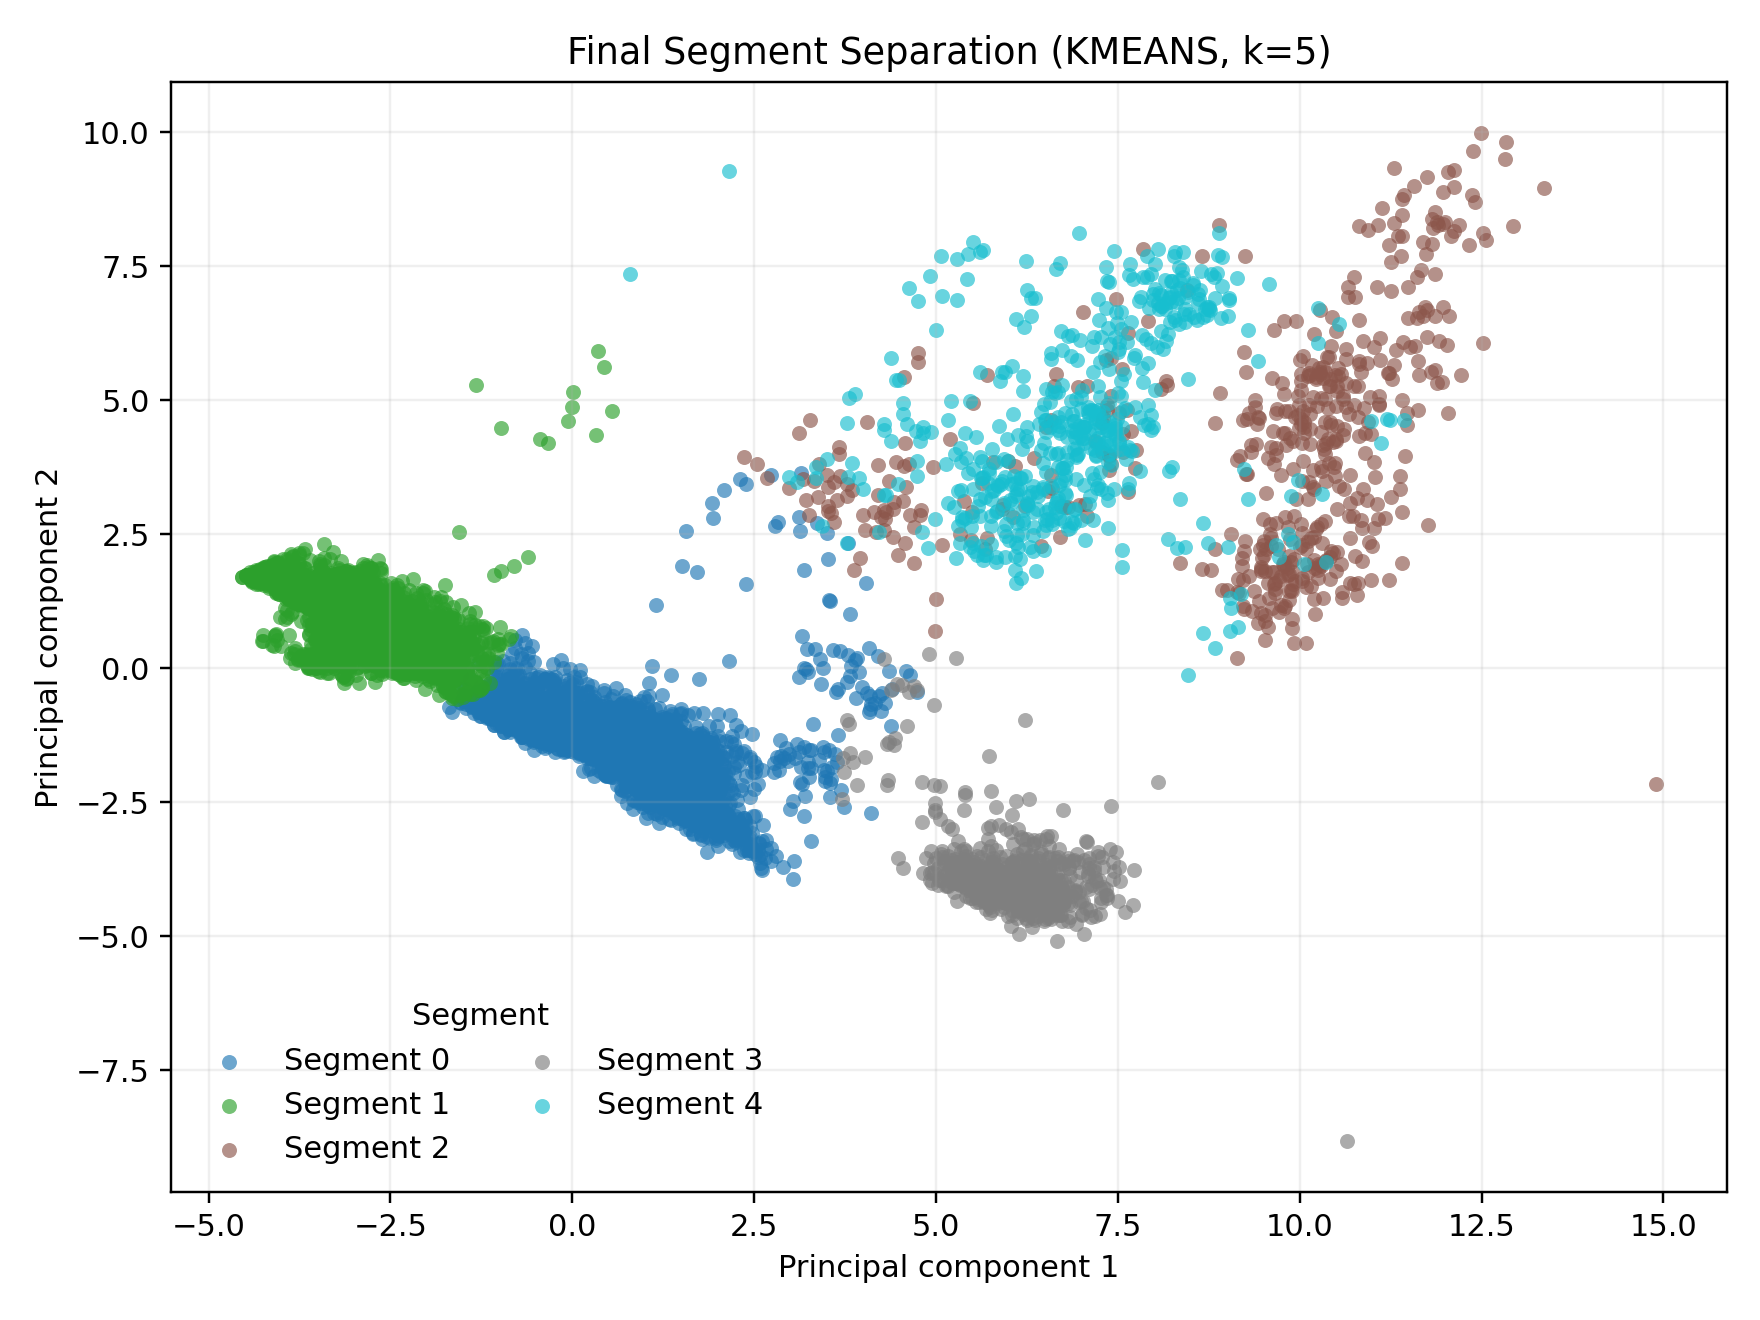

In [9]:
display(Image(filename=str(PROJECT_ROOT / "outputs/figures/segmentation/model_comparison_metrics.png")))
display(Image(filename=str(PROJECT_ROOT / "outputs/figures/segmentation/final_segments_pca.png")))

The final choice is `KMeans` with **5 segments**. It provides the best silhouette among business-usable candidates and cleanly separates high-value spenders, subscription-led value, engaged free users, steady core players, and lapsing casuals.


## 6. Final segmentation and profiles

The profiling step remaps arbitrary cluster IDs into stable business-facing segment IDs and names.


In [10]:
profiling_artifacts = run_profiling()
profiling_artifacts.summary[
    [
        "segment_id",
        "segment_name",
        "user_share_pct",
        "revenue_share_pct",
        "median_sessions",
        "median_recency_days",
        "payer_rate_pct",
        "subscription_payer_rate_pct",
    ]
]

,segment_id,segment_name,user_share_pct,revenue_share_pct,median_sessions,median_recency_days,payer_rate_pct,subscription_payer_rate_pct
0,0,VIP Spenders,4.566,97.208584,262.0,16.0,100.000000,35.085414
1,1,Subscription Loyalists,4.420,2.686388,140.0,17.0,100.000000,99.819005
2,2,Engaged Free Players,6.370,0.000599,300.0,16.0,0.031397,0.000000
3,3,Steady Core Players,39.422,0.081600,44.0,28.0,0.563137,0.000000
4,4,Lapsing Casuals,45.222,0.022830,4.0,122.0,0.256512,0.004423


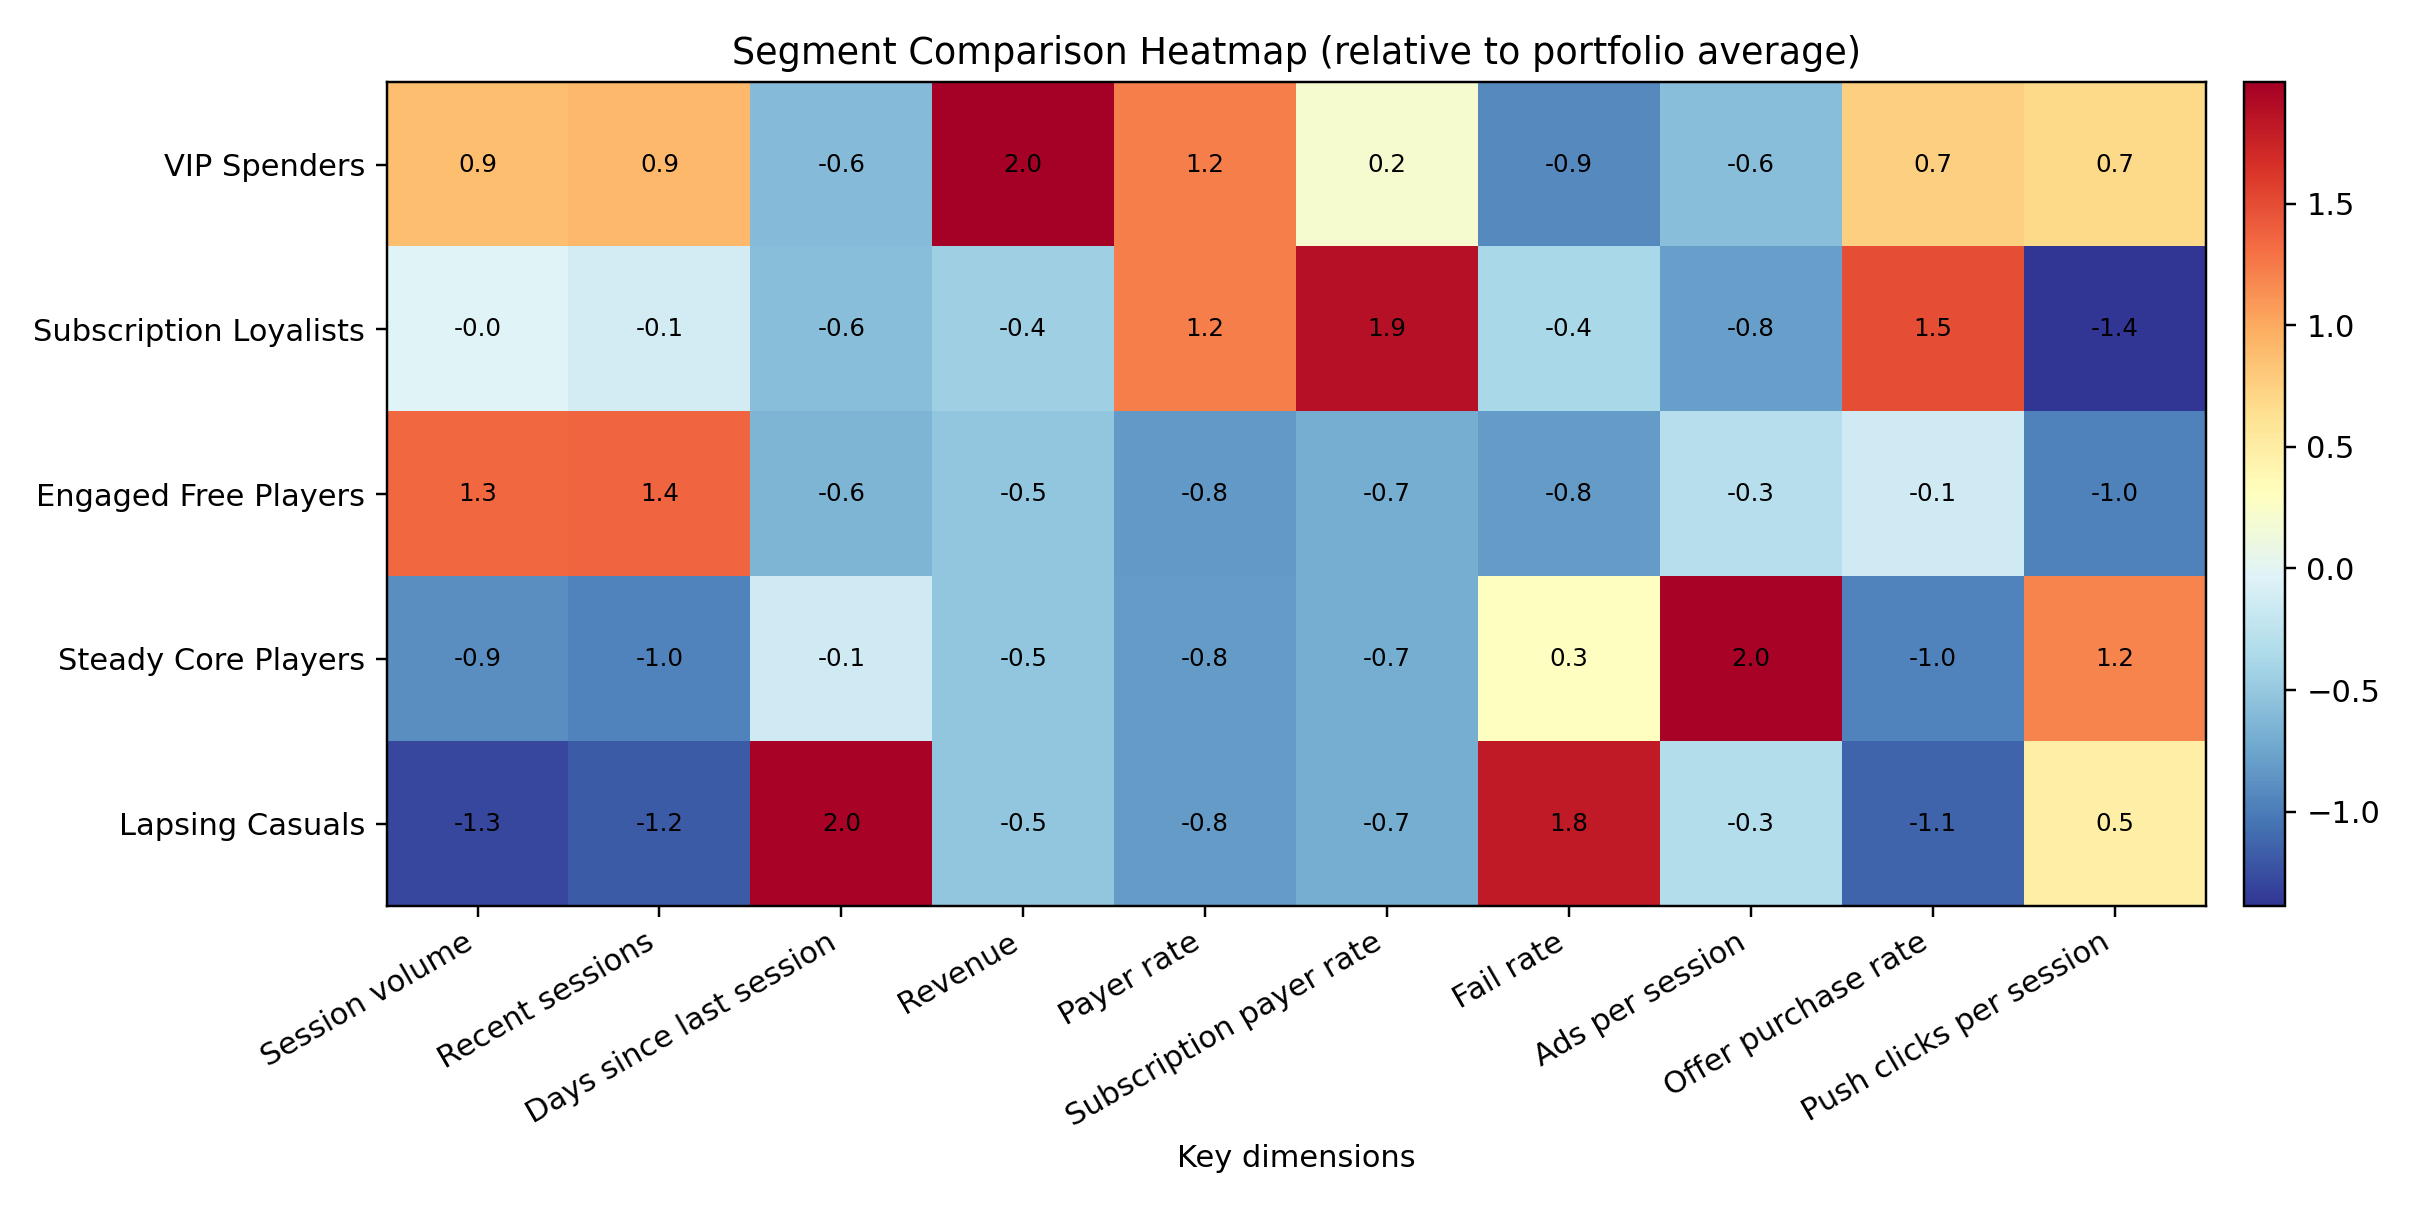

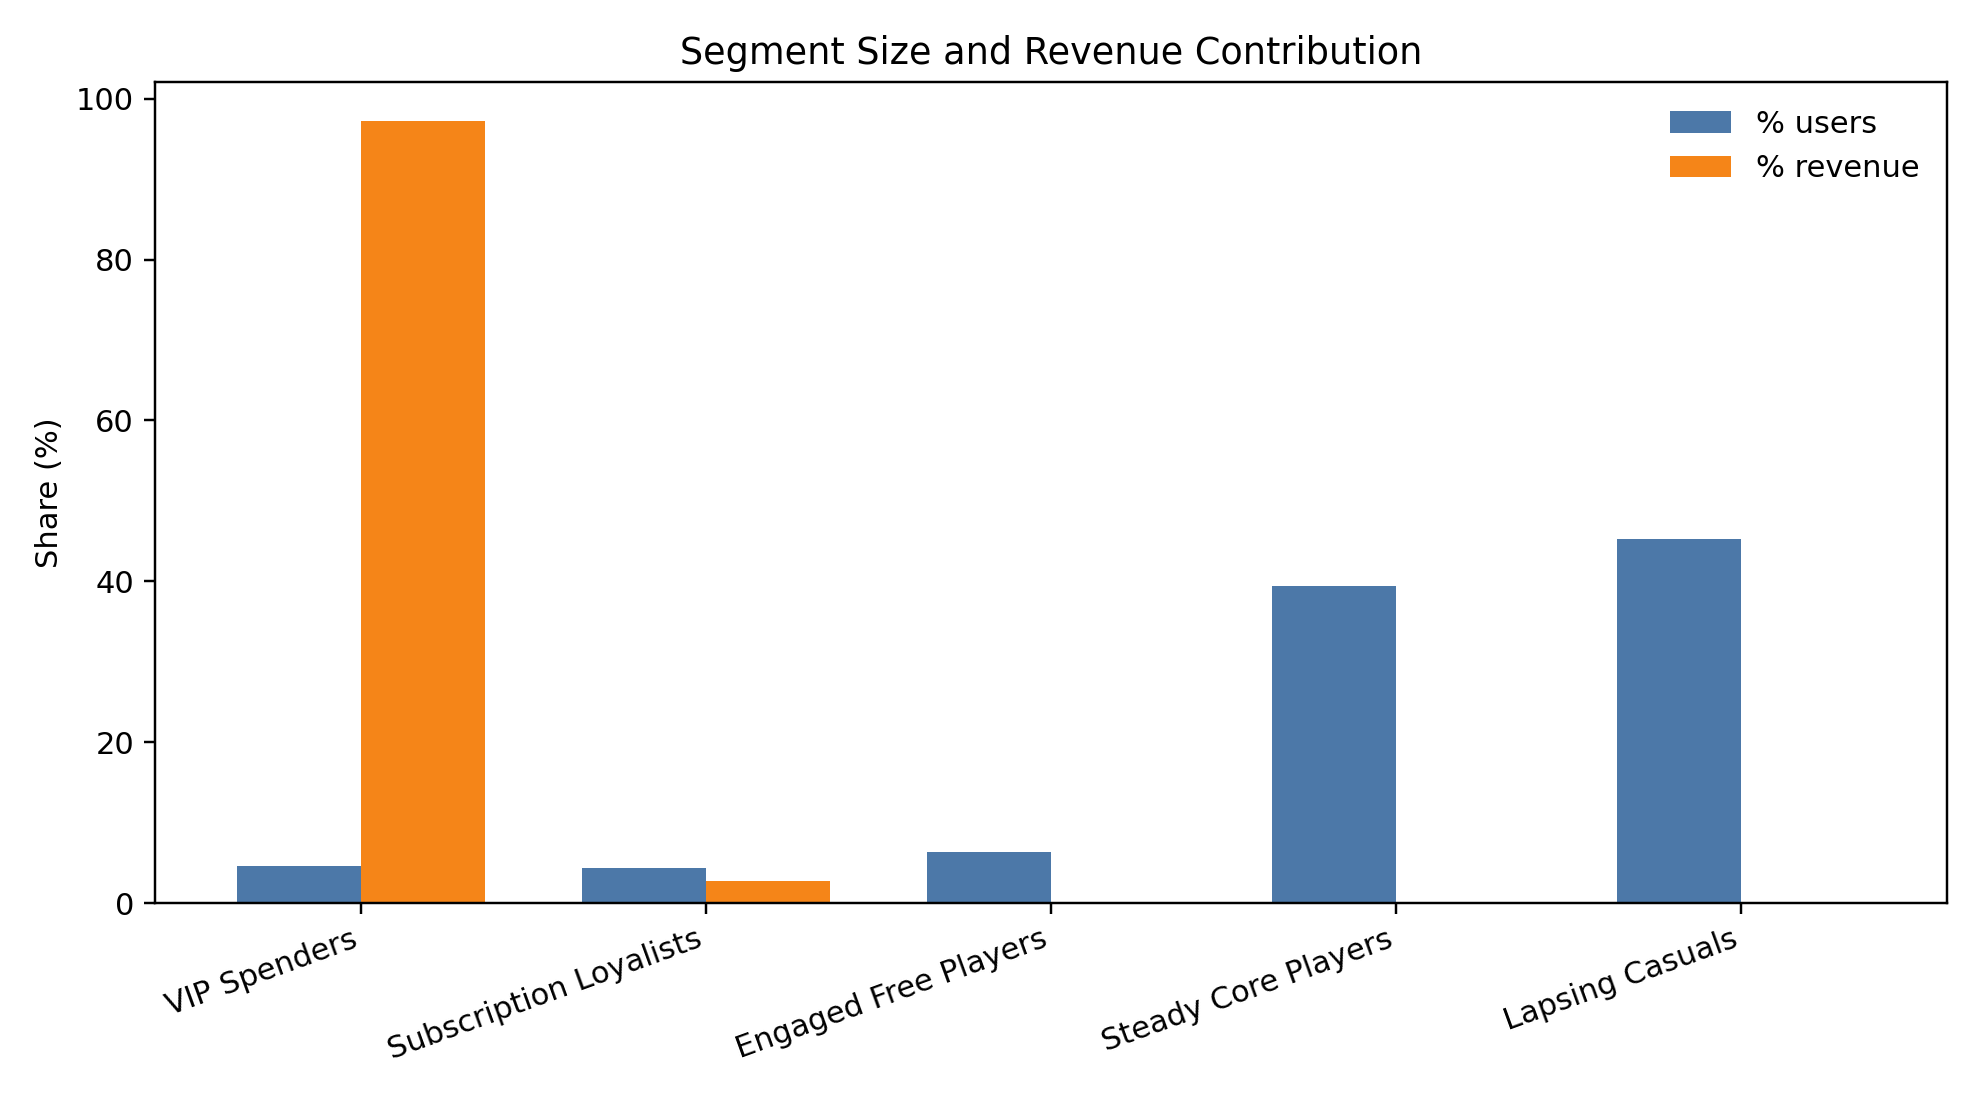

In [11]:
display(Image(filename=str(PROJECT_ROOT / "outputs/figures/segments/segment_comparison_heatmap.png")))
display(Image(filename=str(PROJECT_ROOT / "outputs/figures/segments/segment_size_revenue_share.png")))

## 7. Business recommendations

Recommendations are tied directly to the observed segment behaviors instead of generic mobile gaming playbooks.


In [12]:
profiling_artifacts.recommendation_table[
    [
        "segment_name",
        "recommendation_title",
        "impact_score",
        "ease_score",
    ]
]

,segment_name,recommendation_title,impact_score,ease_score
0,Subscription Loyalists,Reinforce subscription value,4,4
1,Engaged Free Players,Upsell with value-first starter offers,4,4
2,VIP Spenders,Protect with VIP retention treatment,5,3
3,Lapsing Casuals,Run low-friction win-back journeys,3,5
4,Steady Core Players,Develop toward higher-value routines,3,4


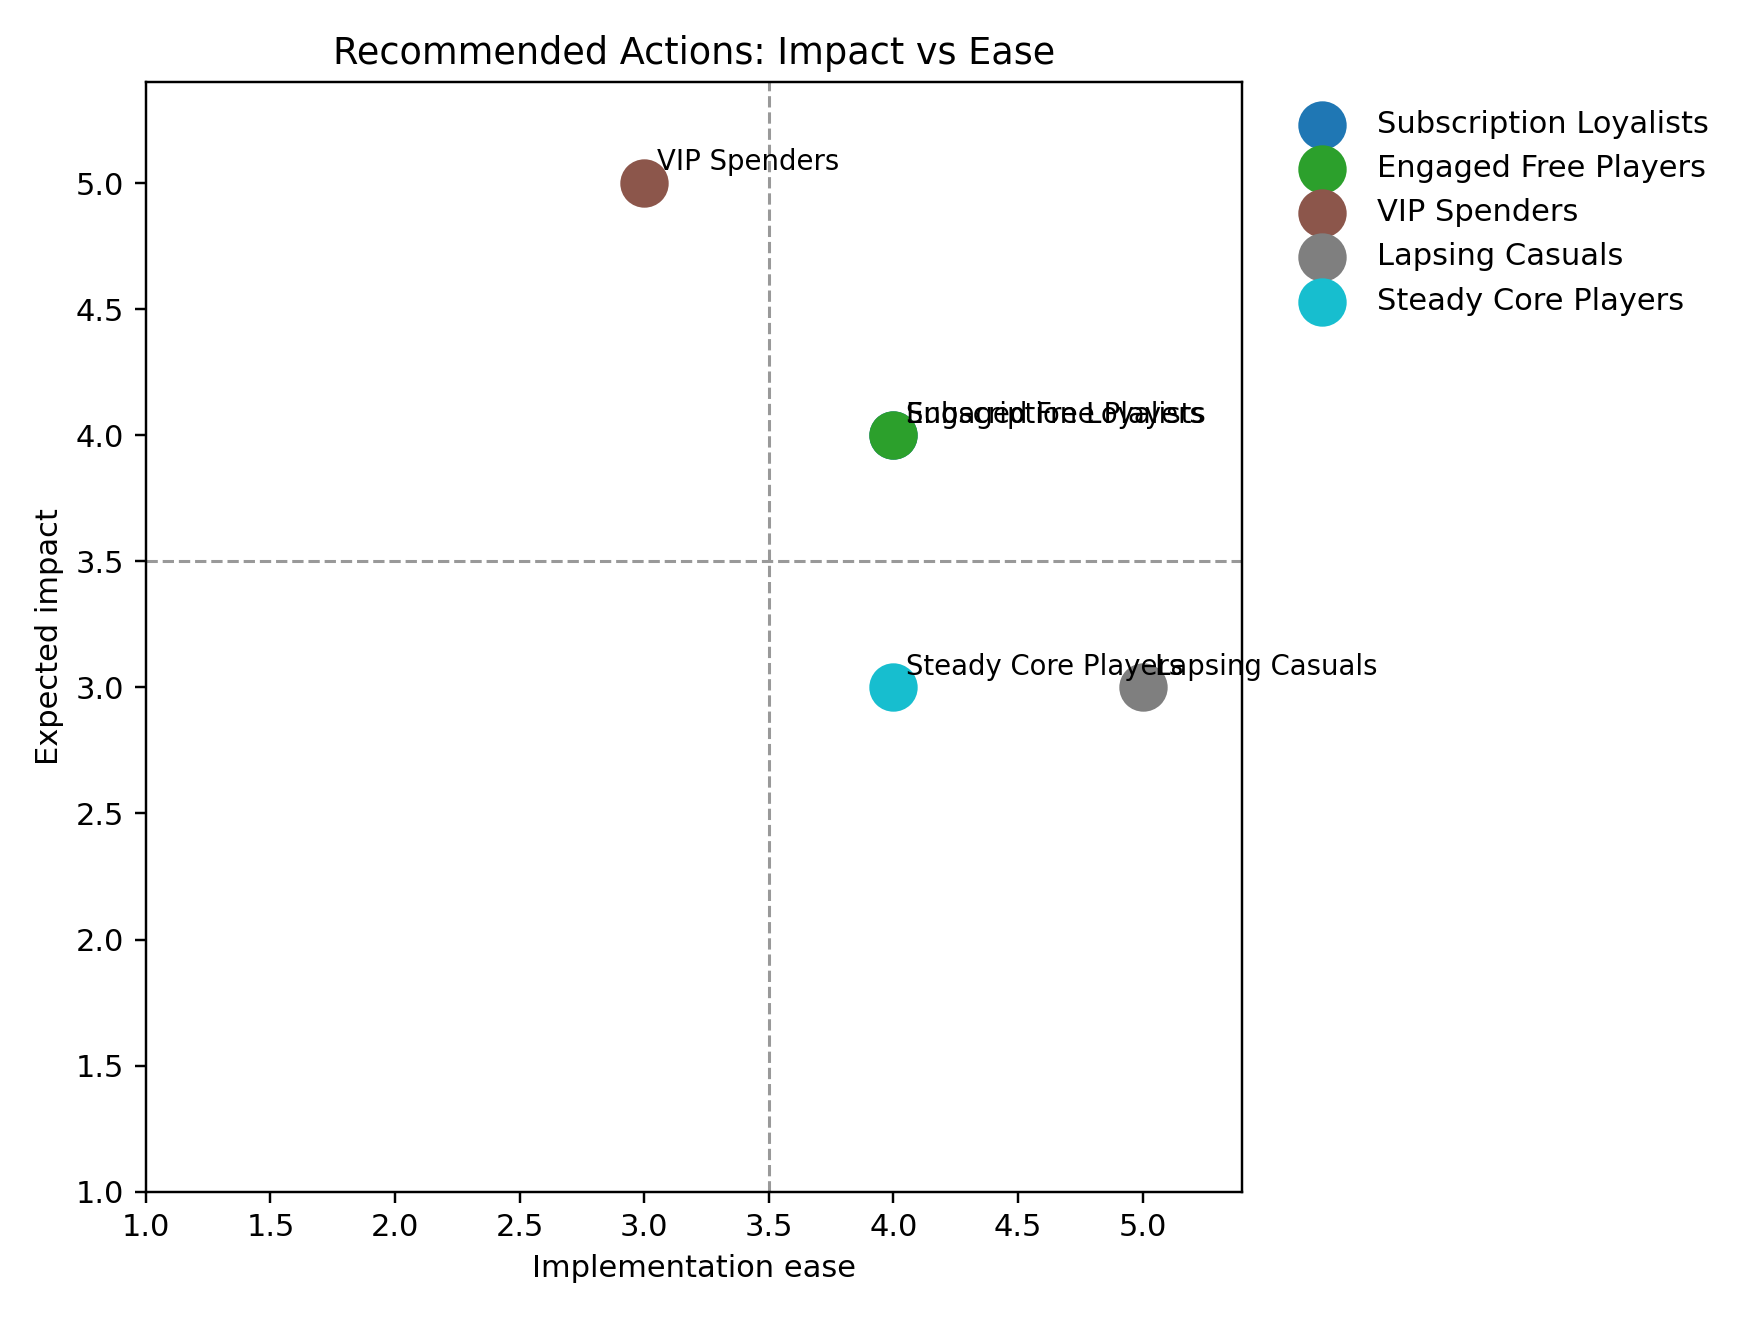

In [13]:
display(Image(filename=str(PROJECT_ROOT / "outputs/figures/business/impact_effort_matrix.png")))

## 8. Caveats and next steps

- This is a portfolio-level segmentation because the behavioral tables do not include `game_id`.
- The segmentation is intentionally practical and interpretable rather than overly complex.
- If more time were available, the next improvements would be stability checks across time windows, selective parsing of event parameters, and light experimentation on segment-specific uplift or response propensity.
